#### Create variable for further analysis 
- Vote share : Proportion of candidate votes out of total votes.
- Flucutation  rate : Measures how much the vote share changes (in absolute value) for the two major parties compared to the previous election year for each state.
- state_national_party_match : Binary variable: 1 if state winner == national winner, 0 otherwise

In [2]:
import pandas as pd
import numpy as np
us_data = pd.read_csv('us_data.csv')
president_data = pd.read_csv('1976-2020-president.csv')
us_data['DATE'] = pd.to_datetime(us_data['DATE'])

# extract state 
us_data['STATE'] = us_data['NAME_1'].str.split('_').str[1].str.upper()
filtered_president_data = president_data[president_data['year'].isin([2008, 2012, 2016, 2020])].copy()

# calculate vote share for each party
filtered_president_data['vote_share'] = (
    filtered_president_data['candidatevotes'] / filtered_president_data['totalvotes']
)

# pivot table
pivot_data = filtered_president_data.pivot_table(
    index=['year', 'state'],
    columns='party_simplified',
    values='vote_share',
    aggfunc='sum'
).reset_index()
pivot_data.fillna(0, inplace=True)

# calculate fluctuation rate
pivot_data['fluctuation_rate'] = (
    pivot_data.groupby('state')[['DEMOCRAT', 'REPUBLICAN']].diff().abs().sum(axis=1)
)
pivot_data['fluctuation_rate'] = pivot_data['fluctuation_rate'].fillna(0)

# Exclude 2008 data for further analysis
pivot_data_filtered = pivot_data[pivot_data['year'] != 2008]

# Add national winning party to pivot_data_filtered
overall_winning_party = {
    2012: 'DEMOCRAT',
    2016: 'REPUBLICAN',
    2020: 'DEMOCRAT'
}

pivot_data_filtered['overall_winning_party'] = pivot_data_filtered['year'].map(overall_winning_party)

# Create state-national party match
pivot_data_filtered['state_winning_party'] = np.where(
    pivot_data_filtered['DEMOCRAT'] > pivot_data_filtered['REPUBLICAN'], 'DEMOCRAT', 'REPUBLICAN'
)
pivot_data_filtered['state_national_party_match'] = (
    pivot_data_filtered['state_winning_party'] == pivot_data_filtered['overall_winning_party']
).astype(int)

# Create time windows 
election_days = {
    2012: pd.to_datetime('2012-11-06'),
    2016: pd.to_datetime('2016-11-08'),
    2020: pd.to_datetime('2020-11-03')
}

# exclude election day and keep only pre/post 5 days
def assign_time_window_updated(row):
    election_day = election_days.get(row['year'])
    if election_day:
        if election_day - pd.Timedelta(days=5) <= row['DATE'] < election_day:  # 前5天
            return 'Pre-election'
        elif election_day < row['DATE'] <= election_day + pd.Timedelta(days=5):  # 后5天
            return 'Post-election'
    return 'Other'

# Add election year
us_data['year'] = us_data['DATE'].dt.year

# Apply the updated time window logic
us_data['time_window'] = us_data.apply(assign_time_window_updated, axis=1)

# Filter relevant time windows (exclude 'Other' and election day)
us_data_filtered = us_data[us_data['time_window'] != 'Other']

# Merge sentiment data with pivoted election data
merged_data = pd.merge(
    us_data_filtered,
    pivot_data_filtered,
    how='left',
    left_on=['year', 'STATE'],
    right_on=['year', 'state']
)

# Final 
cleaned_data = merged_data.drop(columns=['state'])
cleaned_data.to_csv('cleaned_data.csv', index=False)
cleaned_data.head()

/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_93455/1168462151.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot_data_filtered['overall_winning_party'] = pivot_data_filtered['year'].map(overall_winning_party)
/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_93455/1168462151.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot_data_filtered['state_winning_party'] = np.where(
/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_93455/1168462151.py:59: SettingWithCop

,V1,DATE,NAME_0,NAME_1,N,SCORE,STATE,year,time_window,DEMOCRAT,LIBERTARIAN,OTHER,REPUBLICAN,fluctuation_rate,overall_winning_party,state_winning_party,state_national_party_match
0,241665,2012-11-01,United States,United States_Alabama,63,0.549868,ALABAMA,2012,Pre-election,0.383590,0.000000,0.010951,0.605458,0.006103,DEMOCRAT,REPUBLICAN,0
1,241666,2012-11-01,United States,United States_Alaska,3,0.526692,ALASKA,2012,Pre-election,0.408127,0.024599,0.019258,0.548016,0.075462,DEMOCRAT,REPUBLICAN,0
2,241667,2012-11-01,United States,United States_Arizona,44,0.549803,ARIZONA,2012,Pre-election,0.445898,0.013961,0.003596,0.536545,0.005448,DEMOCRAT,REPUBLICAN,0
3,241668,2012-11-01,United States,United States_Arkansas,17,0.511161,ARKANSAS,2012,Pre-election,0.368790,0.015219,0.010322,0.605669,0.038367,DEMOCRAT,REPUBLICAN,0
4,241669,2012-11-01,United States,United States_California,197,0.545501,CALIFORNIA,2012,Pre-election,0.602390,0.010984,0.015422,0.371204,0.009392,DEMOCRAT,DEMOCRAT,1


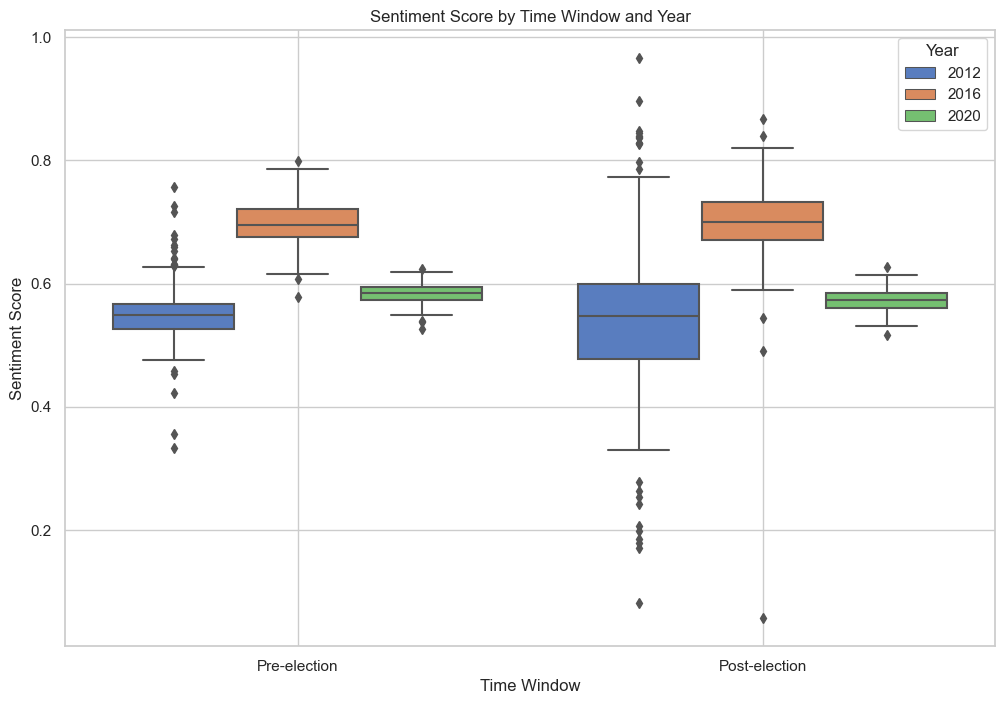

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

visual_data = cleaned_data.dropna(subset=['SCORE', 'fluctuation_rate', 'time_window'])
sns.set(style="whitegrid")

#Sentiment Score Trend by Time Window and Year
plt.figure(figsize=(12, 8))
sns.boxplot(data=visual_data, x='time_window', y='SCORE', hue='year', palette='muted')
plt.title('Sentiment Score by Time Window and Year')
plt.xlabel('Time Window')
plt.ylabel('Sentiment Score')
plt.legend(title='Year', loc='upper right')
plt.grid(True)
plt.show()

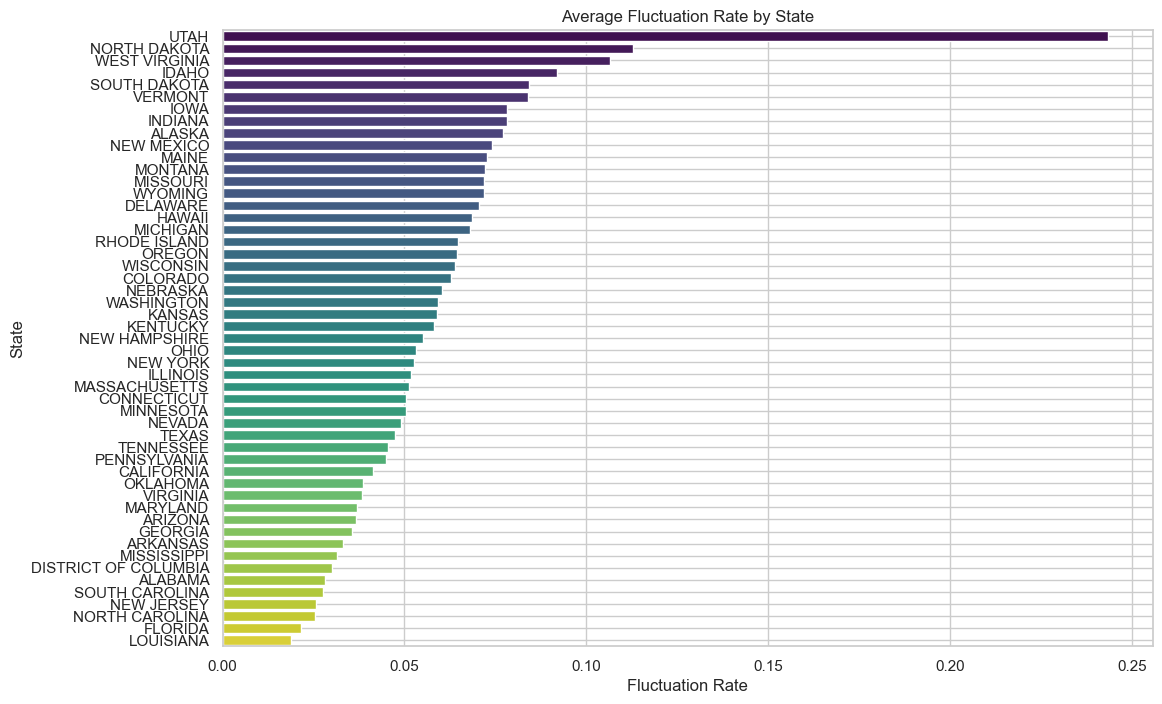

In [6]:
#Heatmap of Fluctuation Rate by State
state_fluctuation = visual_data.groupby('STATE')['fluctuation_rate'].mean().reset_index()
state_fluctuation = state_fluctuation.sort_values('fluctuation_rate', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=state_fluctuation, x='fluctuation_rate', y='STATE', palette='viridis')
plt.title('Average Fluctuation Rate by State')
plt.xlabel('Fluctuation Rate')
plt.ylabel('State')
plt.grid(True)
plt.show()

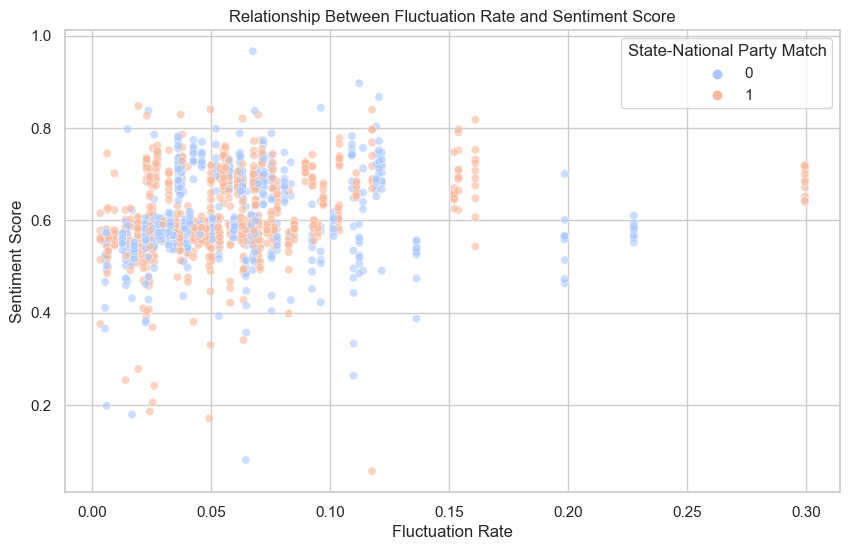

In [7]:
#Scatter Plot - Fluctuation Rate vs Sentiment Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=visual_data, x='fluctuation_rate', y='SCORE', hue='state_national_party_match', palette='coolwarm', alpha=0.6)
plt.title('Relationship Between Fluctuation Rate and Sentiment Score')
plt.xlabel('Fluctuation Rate')
plt.ylabel('Sentiment Score')
plt.legend(title='State-National Party Match', loc='upper right')
plt.grid(True)
plt.show()


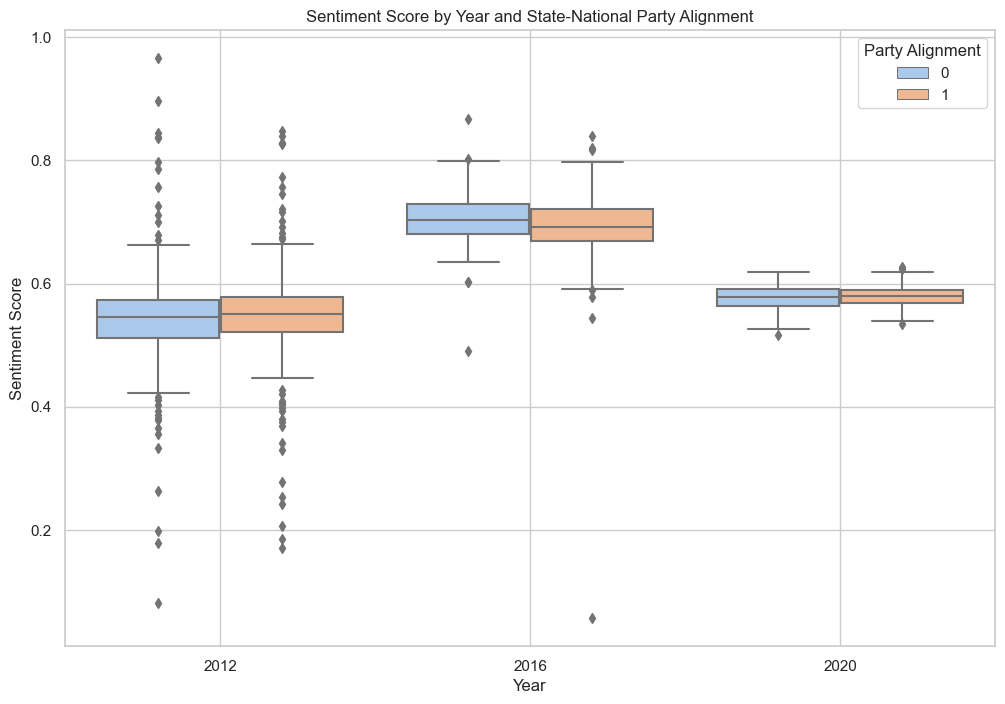

In [8]:
#Sentiment Score Distribution by Year and Party Alignment
plt.figure(figsize=(12, 8))
sns.boxplot(data=visual_data, x='year', y='SCORE', hue='state_national_party_match', palette='pastel')
plt.title('Sentiment Score by Year and State-National Party Alignment')
plt.xlabel('Year')
plt.ylabel('Sentiment Score')
plt.legend(title='Party Alignment', loc='upper right')
plt.grid(True)
plt.show()

In [9]:
# Create `regression_data`
regression_data = cleaned_data.copy()
regression_data['treatment'] = regression_data['state_national_party_match']

# Generate dummy variables for `time_window`
regression_data = pd.get_dummies(regression_data, columns=['time_window'], drop_first=False)

In [12]:
for col in ['time_window_Pre-election','time_window_Post-election']:
    if regression_data[col].dtype == 'bool':
        regression_data[col] = regression_data[col].astype(int)

In [13]:
regression_data

,V1,DATE,NAME_0,NAME_1,N,SCORE,STATE,year,DEMOCRAT,LIBERTARIAN,OTHER,REPUBLICAN,fluctuation_rate,overall_winning_party,state_winning_party,state_national_party_match,treatment,time_window_Post-election,time_window_Pre-election
0,241665,2012-11-01,United States,United States_Alabama,63,0.549868,ALABAMA,2012,0.383590,0.000000,0.010951,0.605458,0.006103,DEMOCRAT,REPUBLICAN,0,0,0,1
1,241666,2012-11-01,United States,United States_Alaska,3,0.526692,ALASKA,2012,0.408127,0.024599,0.019258,0.548016,0.075462,DEMOCRAT,REPUBLICAN,0,0,0,1
2,241667,2012-11-01,United States,United States_Arizona,44,0.549803,ARIZONA,2012,0.445898,0.013961,0.003596,0.536545,0.005448,DEMOCRAT,REPUBLICAN,0,0,0,1
3,241668,2012-11-01,United States,United States_Arkansas,17,0.511161,ARKANSAS,2012,0.368790,0.015219,0.010322,0.605669,0.038367,DEMOCRAT,REPUBLICAN,0,0,0,1
4,241669,2012-11-01,United States,United States_California,197,0.545501,CALIFORNIA,2012,0.602390,0.010984,0.015422,0.371204,0.009392,DEMOCRAT,DEMOCRAT,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,690027,2020-11-08,United States,United States_Virginia,27281,0.581736,VIRGINIA,2020,0.541095,0.014519,0.004431,0.439955,0.047903,DEMOCRAT,DEMOCRAT,1,1,1,0
1480,690028,2020-11-08,United States,United States_Washington,21788,0.579343,WASHINGTON,2020,0.579703,0.019694,0.012934,0.387670,0.073659,DEMOCRAT,DEMOCRAT,1,1,1,0
1481,690029,2020-11-08,United States,United States_West Virginia,3212,0.574033,WEST VIRGINIA,2020,0.296965,0.013449,0.003271,0.686316,0.032206,DEMOCRAT,REPUBLICAN,0,0,1,0
1482,690030,2020-11-08,United States,United States_Wisconsin,10070,0.584372,WISCONSIN,2020,0.494495,0.000000,0.017280,0.488224,0.045999,DEMOCRAT,DEMOCRAT,1,1,1,0


In [14]:
print(regression_data[['time_window_Pre-election', 'time_window_Post-election']].dtypes)
print(regression_data[['time_window_Pre-election','time_window_Post-election']].head())

time_window_Pre-election     int64
time_window_Post-election    int64
dtype: object
   time_window_Pre-election  time_window_Post-election
0                         1                          0
1                         1                          0
2                         1                          0
3                         1                          0
4                         1                          0


In [15]:
print(regression_data.columns)

Index(['V1', 'DATE', 'NAME_0', 'NAME_1', 'N', 'SCORE', 'STATE', 'year',
       'DEMOCRAT', 'LIBERTARIAN', 'OTHER', 'REPUBLICAN', 'fluctuation_rate',
       'overall_winning_party', 'state_winning_party',
       'state_national_party_match', 'treatment', 'time_window_Post-election',
       'time_window_Pre-election'],
      dtype='object')


#### Model Explanation:
This is an Ordinary Least Squares (OLS) regression model with the dependent variable (SCORE) representing the sentiment score. The independent variables include:
- fluctuation_rate: The fluctuation in vote shares.
- treatment: Whether the state’s winning party matches the national winning party.
- time_window_Pre_election, and time_window_Post_election: Dummy variables representing the time windows relative to the election day.

In [16]:
import statsmodels.formula.api as smf
# Verify and recreate dummy variables if needed
if 'time_window_Pre-election' not in regression_data.columns:
    regression_data = pd.get_dummies(regression_data, columns=['time_window'], drop_first=False)

# Replace spaces and special characters in column names with underscores for compatibility
regression_data.columns = regression_data.columns.str.replace('-', '_').str.replace(' ', '_')

# Verify column names
print(regression_data.columns)

# Correct formula based on actual column names
model_basic = smf.ols(
    formula='SCORE ~ fluctuation_rate + treatment + time_window_Pre_election + time_window_Post_election',
    data=regression_data
).fit()

# Display the model summary
print("Basic Regression Model Summary:")
print(model_basic.summary())

Index(['V1', 'DATE', 'NAME_0', 'NAME_1', 'N', 'SCORE', 'STATE', 'year',
       'DEMOCRAT', 'LIBERTARIAN', 'OTHER', 'REPUBLICAN', 'fluctuation_rate',
       'overall_winning_party', 'state_winning_party',
       'state_national_party_match', 'treatment', 'time_window_Post_election',
       'time_window_Pre_election'],
      dtype='object')
Basic Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  SCORE   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     23.93
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           4.01e-15
Time:                        15:30:29   Log-Likelihood:                 1513.2
No. Observations:                1484   AIC:                            -3018.
Df Residuals:                    1480   BIC:                            -2

In [30]:
import pandas as pd

# Creating a structured DataFrame for the Basic Regression Model results
basic_regression_results = pd.DataFrame({
    "Variable": [
        "Intercept",
        "Fluctuation Rate",
        "Treatment",
        "Time Window: Pre-election",
        "Time Window: Post-election"
    ],
    "Coefficient": [
        0.3864, 
        0.4585, 
        0.0047, 
        0.1945, 
        0.1918
    ],
    "Std. Error": [
        0.003, 
        0.055, 
        0.005, 
        0.003, 
        0.003
    ],
    "t-Statistic": [
        124.330, 
        8.381, 
        1.021, 
        71.349, 
        69.129
    ],
    "P-Value": [
        0.000, 
        0.000, 
        0.308, 
        0.000, 
        0.000
    ],
    "CI Lower Bound": [
        0.380, 
        0.351, 
        -0.004, 
        0.189, 
        0.186
    ],
    "CI Upper Bound": [
        0.392, 
        0.566, 
        0.014, 
        0.200, 
        0.197
    ]
})

print("Basic Regression Model Results:")
basic_regression_results

Basic Regression Model Results:


,Variable,Coefficient,Std. Error,t-Statistic,P-Value,CI Lower Bound,CI Upper Bound
0,Intercept,0.3864,0.003,124.330,0.000,0.380,0.392
1,Fluctuation Rate,0.4585,0.055,8.381,0.000,0.351,0.566
2,Treatment,0.0047,0.005,1.021,0.308,-0.004,0.014
3,Time Window: Pre-election,0.1945,0.003,71.349,0.000,0.189,0.200
4,Time Window: Post-election,0.1918,0.003,69.129,0.000,0.186,0.197


1. Intercept (0.3864):
The intercept represents the baseline average sentiment score (SCORE) when all other variables are zero.
2. Fluctuation Rate (0.4585):
This coefficient measures the impact of election competitiveness (fluctuation rate) on sentiment scores.
3. Treatment (0.0047):
The treatment variable indicates the effect of party alignment (whether the state’s political outcome aligns with the national result) on sentiment scores.
4. Time Window: Pre-election (0.1945):
This coefficient captures the sentiment difference during the pre-election period compared to the reference group (likely the election day)
5. Time Window: Post-election (0.1918):
This coefficient represents the difference in sentiment scores during the post-election period compared to the reference group (likely the election day).

In [18]:
print(regression_data[['fluctuation_rate', 'treatment']].corr())

                  fluctuation_rate  treatment
fluctuation_rate           1.00000    0.00901
treatment                  0.00901    1.00000


### Interaction model
This is an interaction model, where the effects of fluctuation_rate, time_window, and treatment on SCORE are analyzed. The inclusion of interaction terms allows us to investigate whether the effects of fluctuation_rate and time windows differ depending on the treatment status (whether the state’s winning party matches the national winning party).

In [19]:
model_interaction = smf.ols(
    formula='SCORE ~ fluctuation_rate * treatment* treatment + time_window_Post_election * treatment',
    data=regression_data
).fit()
print("\nInteraction Model Summary:")
print(model_interaction.summary())


Interaction Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  SCORE   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     15.84
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           3.17e-15
Time:                        15:36:00   Log-Likelihood:                 1516.8
No. Observations:                1484   AIC:                            -3022.
Df Residuals:                    1478   BIC:                            -2990.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [21]:
import pandas as pd

# Creating a structured DataFrame for the Interaction Model results
interaction_model_results = pd.DataFrame({
    "Variable": [
        "Intercept",
        "Fluctuation Rate",
        "Treatment",
        "Fluctuation Rate x Treatment",
        "Time Window: Post-election",
        "Time Window: Post-election x Treatment"
    ],
    "Coefficient": [
        0.5915,
        0.2937,
        -0.0141,
        0.2928,
        -0.0045,
        0.0029
    ],
    "Std. Error": [
        0.007,
        0.083,
        0.009,
        0.110,
        0.007,
        0.009
    ],
    "t-Statistic": [
        87.180,
        3.560,
        -1.549,
        2.659,
        -0.675,
        0.323
    ],
    "P-Value": [
        0.000,
        0.000,
        0.122,
        0.008,
        0.500,
        0.747
    ],
    "CI Lower Bound": [
        0.578,
        0.132,
        -0.032,
        0.077,
        -0.018,
        -0.015
    ],
    "CI Upper Bound": [
        0.605,
        0.456,
        0.004,
        0.509,
        0.009,
        0.021
    ]
})

# Display the results table
interaction_model_results

,Variable,Coefficient,Std. Error,t-Statistic,P-Value,CI Lower Bound,CI Upper Bound
0,Intercept,0.5915,0.007,87.180,0.000,0.578,0.605
1,Fluctuation Rate,0.2937,0.083,3.560,0.000,0.132,0.456
2,Treatment,-0.0141,0.009,-1.549,0.122,-0.032,0.004
3,Fluctuation Rate x Treatment,0.2928,0.110,2.659,0.008,0.077,0.509
4,Time Window: Post-election,-0.0045,0.007,-0.675,0.500,-0.018,0.009
5,Time Window: Post-election x Treatment,0.0029,0.009,0.323,0.747,-0.015,0.021


#### Key Results
##### 1.	Model Fit:
- R-squared = 0.058:
- The model explains 5.8% of the variance in the sentiment score, slightly better than the basic regression model.
- Adj. R-squared = 0.051:
- After adjusting for the number of predictors, the model explains 5.1% of the variance.
##### 2.	Statistical Significance (Prob (F-statistic)):
- The overall model is statistically significant (p < 0.001), indicating that at least one predictor significantly impacts SCORE.
##### 3.	Coefficients and Effects:
- Intercept = 0.5954:
- Baseline sentiment score when all other predictors are zero.
- Main Effects:
- fluctuation_rate = 0.2639:
- A 1-unit increase in fluctuation rate increases the sentiment score by 0.2639, holding other variables constant (p = 0.005).
- treatment = -0.0191:
- Treatment (state-national alignment) reduces the sentiment score by 0.0191, but this effect is marginally significant (p = 0.077).
- time_window_Election_day = -0.0022:
- No significant effect of election day on sentiment compared to the baseline (p = 0.849).
- time_window_Post_election = -0.0174:
- Post-election sentiment is 0.0174 units lower than the baseline, a small but significant decrease (p = 0.035).
- Interaction Effects:
- fluctuation_rate:treatment = 0.3252:
- The effect of fluctuation rate on sentiment increases by 0.3252 when treatment = 1 (state aligns with the national party), and this is statistically significant (p = 0.009).
- time_window_Election_day:treatment = 0.0003:
- No significant interaction between election day and treatment (p = 0.986).
- time_window_Post_election:treatment = 0.0111:
- No significant interaction between post-election and treatment (p = 0.320).
##### 4.	Residual Diagnostics:
- Omnibus and Jarque-Bera Tests:
- The residuals are not normally distributed (significant p-values).
- Durbin-Watson = 1.005:
- Indicates potential positive autocorrelation in residuals.

#### Interpretation of Results
##### 1.	Fluctuation Rate:
- Fluctuation rate positively impacts sentiment scores, and this effect is amplified when the state aligns with the national winning party (treatment = 1).
##### 2.	Treatment:
- The direct effect of treatment on sentiment is slightly negative and marginally significant, suggesting limited influence on its own.
##### 3.	Time Windows:
- Post-election periods show a small but significant drop in sentiment compared to the baseline.
- The election day effect is negligible.
##### 4.	Interaction Effects:
- The most notable interaction is between fluctuation_rate and treatment

### DID Model Results
The Difference-in-Differences (DID) model uses a combination of time indicators (year), treatment indicators (treatment), and interaction terms to analyze changes in the dependent variable (SCORE) attributable to the treatment over time.

In [23]:
# pre
pre_treatment_data = regression_data[regression_data['year'] < 2016]

# regression 
parallel_trend_model = smf.ols(
    formula='SCORE ~ C(year) * treatment',
    data=pre_treatment_data
).fit()

# result
print(parallel_trend_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  SCORE   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.2661
Date:                Mon, 16 Dec 2024   Prob (F-statistic):              0.606
Time:                        15:37:58   Log-Likelihood:                 438.46
No. Observations:                 464   AIC:                            -872.9
Df Residuals:                     462   BIC:                            -864.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5439      0.006     84.215      0.0

In [25]:
model_did = smf.ols(
    formula='SCORE ~ treatment* time_window_Post_election + fluctuation_rate + C(year)',
    data=regression_data
).fit()
print("\nDifference-in-Differences (DID) Model Summary:")
print(model_did.summary())


Difference-in-Differences (DID) Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  SCORE   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     281.0
Date:                Mon, 16 Dec 2024   Prob (F-statistic):          4.33e-240
Time:                        15:38:33   Log-Likelihood:                 2043.1
No. Observations:                1484   AIC:                            -4072.
Df Residuals:                    1477   BIC:                            -4035.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

Key Outputs:
##### 1.	Model Fit (R-squared and Adj. R-squared):
- R-squared = 0.576:
- The model explains 57.6% of the variance in sentiment scores, indicating a strong fit compared to the earlier models.
- Adj. R-squared = 0.573:
- After adjusting for the number of predictors, the model still explains 57.3% of the variance.
##### 2.	Statistical Significance (Prob (F-statistic)):
- The overall model is highly significant (p < 0.001), meaning at least one predictor or interaction term significantly affects the sentiment score.
##### 3.	Coefficients and Their Interpretation:
- Intercept = 0.5539:
- Baseline sentiment score for the reference group (year = 2012, pre-election period, treatment = 0).
- Year Effects:
- C(year)[T.2016] = 0.1512:
- Sentiment scores in 2016 are 0.1512 units higher compared to the baseline year (2012), holding other factors constant (p < 0.001).
- C(year)[T.2020] = 0.0326:
- Sentiment scores in 2020 are 0.0326 units higher compared to 2012 (p < 0.001).
- This indicates that election years differ in their overall sentiment trends.
- Treatment Effects:
- When states align with the national winning party, sentiment scores decrease by 0.0080, but this is not statistically significant (p = 0.130).
- Time Window Effects:
- time_window_Election_day = -0.0022:
- Election day sentiment does not significantly differ from the reference period (p = 0.777).
- time_window_Post_election = -0.0194:
- Post-election sentiment is 0.0194 units lower compared to the pre-election period (p < 0.001).
- Interaction Terms:
- treatment:time_window_Election_day = 0.0003:
- No significant interaction between treatment and election day sentiment (p = 0.979).
- treatment:time_window_Post_election = 0.0116:
- The interaction between treatment and post-election period is not significant (p = 0.121).
- Fluctuation Rate:
- fluctuation_rate = 0.0057:
- Fluctuation rate has a negligible and non-significant effect on sentiment (p = 0.896).

#### Interpretation of Results
##### 1.	Yearly Trends:
- Sentiment scores vary significantly across election years, with 2016 showing the largest increase relative to 2012.
- The 2020 election shows a smaller but still significant increase in sentiment compared to 2012.
##### 2.	Treatment (State-National Alignment):
- State alignment with the national winning party does not significantly affect sentiment scores.
- This suggests that political alignment may not be a critical factor in shaping public sentiment.
##### 3.	Time Window Effects:
- Post-election periods consistently show lower sentiment scores, but the interaction with treatment is not significant. This indicates that the decline is likely a general trend, not specific to aligned or misaligned states.
##### 4.	Fluctuation Rate:
- Fluctuation rate has no significant direct effect on sentiment. This suggests that changes in vote share dynamics do not independently drive sentiment.

#### Conclusion
- The DID model provides valuable insights into the temporal and political dynamics of public sentiment:
- Year effects are the strongest predictors, showing that sentiment scores differ significantly across election cycles.
- Treatment and interaction terms have limited explanatory power, indicating that state-national alignment does not strongly influence sentiment trends.
- Time windows highlight a consistent post-election decline in sentiment but without meaningful interaction effects.

In [26]:
data_2012 = regression_data[regression_data['year'] == 2012]
data_2016 = regression_data[regression_data['year'] == 2016]
data_2020 = regression_data[regression_data['year'] == 2020]

In [27]:
for data in [data_2012, data_2016, data_2020]:
    data['post'] = (data['DATE'] >= pd.Timestamp(f"{data['year'].iloc[0]}-11-03")).astype(int)

/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_10828/3624787641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['post'] = (data['DATE'] >= pd.Timestamp(f"{data['year'].iloc[0]}-11-03")).astype(int)
/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_10828/3624787641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['post'] = (data['DATE'] >= pd.Timestamp(f"{data['year'].iloc[0]}-11-03")).astype(int)
/var/folders/tv/lvhrg8md4gs4fq49xnk5b4h00000gn/T/ipykernel_10828/362478764

In [28]:
import statsmodels.formula.api as smf

for year, data in zip([2012, 2016, 2020], [data_2012, data_2016, data_2020]):
    model_did = smf.ols(
        formula='SCORE ~ treatment * post + fluctuation_rate',
        data=data
    ).fit()
    print(f"\nDID Model Summary for {year}:")
    print(model_did.summary())


DID Model Summary for 2012:
                            OLS Regression Results                            
Dep. Variable:                  SCORE   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.3850
Date:                Mon, 16 Dec 2024   Prob (F-statistic):              0.819
Time:                        15:39:15   Log-Likelihood:                 439.10
No. Observations:                 464   AIC:                            -868.2
Df Residuals:                     459   BIC:                            -847.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept  

In [29]:
import pandas as pd

# Creating a structured DataFrame for the DID model results
did_model_results = pd.DataFrame({
    "Year": [2012, 2016, 2020],
    "Intercept": [0.5366, 0.3555, 0.5785],
    "Treatment Coef": [0.0126, -0.0060, -0.0019],
    "Treatment P-Value": [0.510, 0.009, 0.344],
    "Post Coef": [-0.0009, 0.3555, -0.0141],
    "Post P-Value": [0.956, 0.000, 0.000],
    "Interaction Coef (Treatment:Post)": [-0.0057, -0.0060, 0.0064],
    "Interaction P-Value": [0.787, 0.009, 0.026],
    "Fluctuation Rate Coef": [0.1271, -0.0868, 0.1150],
    "Fluctuation Rate P-Value": [0.303, 0.073, 0.000],
    "R-Squared": [0.003, 0.023, 0.156]
})

did_model_results

,Year,Intercept,Treatment Coef,Treatment P-Value,Post Coef,Post P-Value,Interaction Coef (Treatment:Post),Interaction P-Value,Fluctuation Rate Coef,Fluctuation Rate P-Value,R-Squared
0,2012,0.5366,0.0126,0.510,-0.0009,0.956,-0.0057,0.787,0.1271,0.303,0.003
1,2016,0.3555,-0.0060,0.009,0.3555,0.000,-0.0060,0.009,-0.0868,0.073,0.023
2,2020,0.5785,-0.0019,0.344,-0.0141,0.000,0.0064,0.026,0.1150,0.000,0.156
